# Scaling and encoding

Goals:
- Inspect numerical features via boxplots to flag anomalies.
- Use `RobustScaler` where outliers are present, else `StandardScaler`.
- One-hot encode categorical columns.
- Fit on train only; transform train/val/test to avoid leakage.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [2]:
X_train = pd.read_csv('data/X_train.csv')

X_train.shape

(4910, 592)

In [3]:
# Identify column types
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X_train.select_dtypes(exclude=['object', 'category']).columns.tolist()

# Remove area log from scaling; keep for passthrough
AREA_LOG_COL = 'log1p_area_thousand_ha'
if AREA_LOG_COL in num_cols:
    num_cols = [c for c in num_cols if c != AREA_LOG_COL]

cat_cols, len(num_cols)

(['province_name', 'commodity', 'season'], 589)

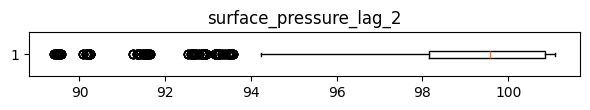

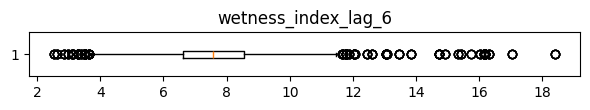

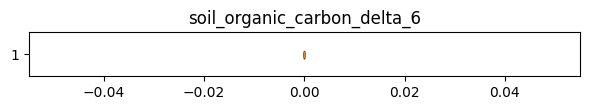

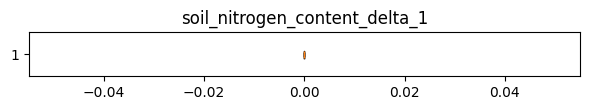

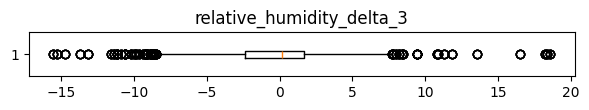

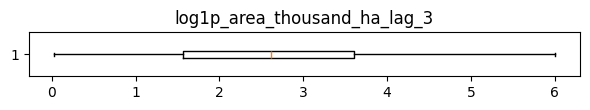

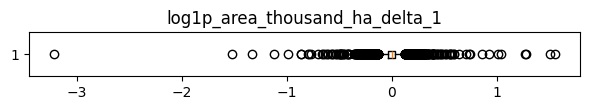

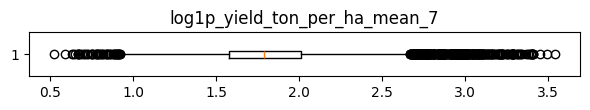

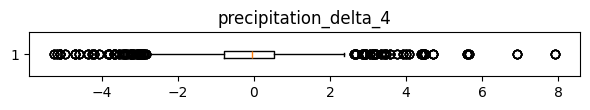

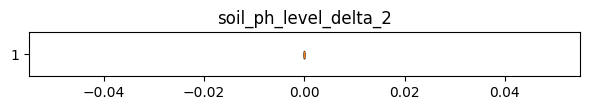

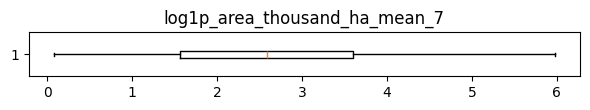

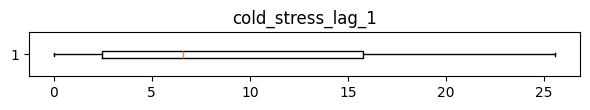

Plotted 12 sampled numerical columns out of 589.


In [4]:
# Boxplots for a sample of numerical columns to avoid hundreds of figures
import random
sample_size = min(12, len(num_cols))
sample_cols = random.sample(num_cols, sample_size)

for col in sample_cols:
    plt.figure(figsize=(6, 1.2))
    plt.boxplot(X_train[col].dropna(), vert=False)
    plt.title(col)
    plt.tight_layout()
    plt.show()
plt.close('all')
print(f"Plotted {sample_size} sampled numerical columns out of {len(num_cols)}.")

In [5]:
# Flag columns with outliers using IQR rule
outlier_fraction = {}
for col in num_cols:
    series = X_train[col].dropna()
    if series.empty:
        outlier_fraction[col] = 0.0
        continue
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    frac = ((series < lower) | (series > upper)).mean()
    outlier_fraction[col] = frac

robust_cols = [c for c, frac in outlier_fraction.items() if frac > 0.01]
standard_cols = [c for c in num_cols if c not in robust_cols]

len(robust_cols), len(standard_cols)

(298, 291)

In [6]:
# ColumnTransformer for scaling + encoding
robust_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

standard_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('robust_num', robust_pipe, robust_cols),
        ('standard_num', standard_pipe, standard_cols),
        ('cat', cat_pipe, cat_cols)
    ],
    remainder='drop',
    verbose_feature_names_out=False
)

In [7]:
# Fit on train; transform all splits to avoid leakage
preprocessor.fit(X_train)
feature_names = preprocessor.get_feature_names_out()

X_train_scaled = pd.DataFrame(preprocessor.transform(X_train), columns=feature_names)
X_train_scaled.shape

(4910, 661)

In [8]:
# Quick check on resulting features
cat_feature_names = [f for f in feature_names if f not in robust_cols and f not in standard_cols]
print('Robust-scaled numerical:', len(robust_cols))
print('Standard-scaled numerical:', len(standard_cols))
print('One-hot encoded features:', len(cat_feature_names))
X_train_scaled.head()

Robust-scaled numerical: 298
Standard-scaled numerical: 291
One-hot encoded features: 72


,avg_temperature_delta_1,avg_temperature_delta_3,avg_temperature_delta_4,avg_temperature_delta_5,avg_temperature_delta_7,min_temperature_delta_2,min_temperature_delta_3,min_temperature_delta_5,max_temperature_delta_1,max_temperature_delta_2,...,province_name_Vinh Phuc,province_name_Yen Bai,commodity_cassava,commodity_maize,commodity_rice,commodity_sweet_potato,season_annual,season_main_rainy,season_summer_autumn_fall,season_winter_spring
0,1.138790,2.272018,-0.328829,1.407281,0.518966,0.084270,1.601036,1.087379,0.404858,0.582744,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,-0.342823,1.227425,1.649550,-0.737201,0.925000,0.084270,0.046632,-0.029126,0.044534,0.424328,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.018980,0.875139,1.080180,2.108077,0.954310,1.106742,0.886010,2.470874,-0.210526,-0.435644,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,-0.014235,-0.208473,0.770270,1.357224,-0.431897,0.033708,0.000000,0.087379,0.368421,0.016973,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,-0.489917,-0.346711,-0.466667,0.509670,1.354310,-0.943820,-0.062176,0.029126,-0.275304,-0.073550,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [9]:
# Save the fitted preprocessor for inference pipeline
import joblib

models_dir = Path('models')
models_dir.mkdir(parents=True, exist_ok=True)

preprocessor_path = models_dir / 'preprocessor.joblib'
joblib.dump(preprocessor, preprocessor_path)
print(f"Saved preprocessor to {preprocessor_path}")

Saved preprocessor to models\preprocessor.joblib
